# 02 — Final exploratory data analysis

Reproduces only the EDA used in the submitted report, using the final harmonised
\(M_w^\ast\ge2.5\) catalogue:

- annual/monthly temporal distribution;
- cumulative spatial distribution; and
- daily grid-cell sparsity.

Development-only seasonal and hour-of-day plots are omitted.

In [1]:
# ============================================================
# 0. Imports and project configuration
# ============================================================

from pathlib import Path
from io import BytesIO
import zipfile
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
AUDIT_DIR = OUTPUT_DIR / "audit"

for _d in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, PRED_DIR, AUDIT_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

GRID_MASK_FILE = DATA_DIR / "california_grid_centre_mask.csv"
FINAL_MW25_FILE = DATA_DIR / "earthquake_california_grid_2010_2025_Mw25_centre_mask.csv"

START_YEAR = 2010
END_YEAR = 2025

LAT_MIN, LAT_MAX = 32.0, 42.5
LON_MIN, LON_MAX = -125.0, -114.0

N_LAT = 53
N_LON = 55

LAT_EDGES = np.linspace(LAT_MIN, LAT_MAX, N_LAT + 1)
LON_EDGES = np.linspace(LON_MIN, LON_MAX, N_LON + 1)

print("Working directory:", DATA_DIR.resolve())
print("Latitude cell width:", LAT_EDGES[1] - LAT_EDGES[0])
print("Longitude cell width:", LON_EDGES[1] - LON_EDGES[0])


Working directory: E:\test\california_earthquake_forecasting_reproducible\data
Latitude cell width: 0.19811320754716633
Longitude cell width: 0.20000000000000284


In [2]:
# ============================================================
# 1. Load the final harmonised catalogue and centre-based grid mask
# ============================================================

if not FINAL_MW25_FILE.exists():
    raise FileNotFoundError(
        f"Missing {FINAL_MW25_FILE}. Run the magnitude-harmonisation "
        "pipeline first so that the final Mw* >= 2.5 catalogue is saved."
    )

if not GRID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Missing {GRID_MASK_FILE}."
    )

df_final = pd.read_csv(FINAL_MW25_FILE)
grid_mask = pd.read_csv(GRID_MASK_FILE)

df_final["time"] = pd.to_datetime(df_final["time"], format="mixed", utc=True)

required_mask_cols = {"cell_id", "lat_idx", "lon_idx", "is_california"}
missing = required_mask_cols - set(grid_mask.columns)
if missing:
    raise ValueError(f"Grid mask is missing columns: {sorted(missing)}")

assert len(grid_mask) == 1080
assert grid_mask["cell_id"].is_unique
assert grid_mask["is_california"].fillna(False).all()

print("Final harmonised events:", f"{len(df_final):,}")
print("Retained California cells:", len(grid_mask))
print("Occupied cells:", df_final["cell_id"].nunique())
print("Time range:", df_final["time"].min(), "to", df_final["time"].max())


Final harmonised events: 30,347
Retained California cells: 1080
Occupied cells: 746
Time range: 2010-01-01 02:55:04.370000+00:00 to 2025-12-31 15:28:39+00:00


In [3]:
# ============================================================
# 2. Prepare annual and monthly earthquake counts
# ============================================================

df_eda = df_final.copy()

df_eda["year"] = df_eda["time"].dt.year
df_eda["month"] = (
    df_eda["time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

df_eda = df_eda[
    (df_eda["year"] >= START_YEAR) &
    (df_eda["year"] <= END_YEAR)
].copy()

annual_counts = (
    df_eda.groupby("year")
    .size()
    .reindex(range(START_YEAR, END_YEAR + 1), fill_value=0)
)

all_months = pd.period_range(
    f"{START_YEAR}-01",
    f"{END_YEAR}-12",
    freq="M"
)

monthly_counts = (
    df_eda.groupby("month")
    .size()
    .reindex(all_months, fill_value=0)
)

rolling_12m = (
    monthly_counts
    .rolling(window=12, center=True, min_periods=6)
    .mean()
)

print("Annual earthquake counts")
print("------------------------")
print(annual_counts)

print("\nFive highest annual counts")
print("--------------------------")
print(annual_counts.sort_values(ascending=False).head(5))

print("\nTen highest monthly counts")
print("--------------------------")
print(monthly_counts.sort_values(ascending=False).head(10))

count_2019 = annual_counts.loc[2019]
count_july_2019 = monthly_counts.loc[pd.Period("2019-07", freq="M")]
share_july_2019 = 100 * count_july_2019 / count_2019

print("\n2019 Ridgecrest-period summary")
print("------------------------------")
print(f"2019 annual count: {count_2019:,}")
print(f"July 2019 count:   {count_july_2019:,}")
print(f"July share of 2019: {share_july_2019:.1f}%")

assert annual_counts.sum() == len(df_eda)
assert monthly_counts.sum() == len(df_eda)

print("\nConsistency checks passed.")


Annual earthquake counts
------------------------
year
2010    3792
2011    1224
2012    1457
2013    1343
2014    1316
2015    1082
2016    1329
2017    1240
2018    1129
2019    6623
2020    2310
2021    2181
2022    1282
2023    1323
2024    1478
2025    1238
dtype: int64

Five highest annual counts
--------------------------
year
2019    6623
2010    3792
2020    2310
2021    2181
2024    1478
dtype: int64

Ten highest monthly counts
--------------------------
2019-07    4662
2010-04    1684
2010-06     487
2019-08     458
2020-10     432
2010-05     408
2021-07     406
2021-06     397
2012-08     352
2020-06     305
Freq: M, dtype: int64

2019 Ridgecrest-period summary
------------------------------
2019 annual count: 6,623
July 2019 count:   4,662
July share of 2019: 70.4%

Consistency checks passed.


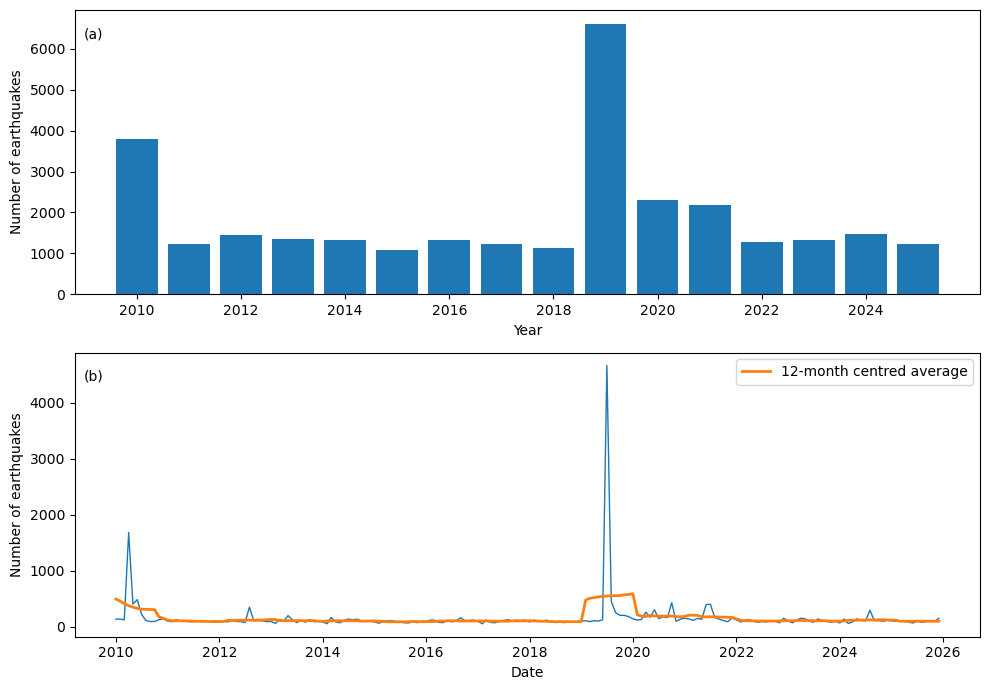

In [4]:
# ============================================================
# 3. Temporal-distribution figure
# ============================================================

monthly_dates = monthly_counts.index.to_timestamp()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7)
)

# (a) Annual counts
axes[0].bar(
    annual_counts.index,
    annual_counts.values
)

axes[0].set_ylabel("Number of earthquakes")
axes[0].set_xlabel("Year")
axes[0].set_xticks(range(START_YEAR, END_YEAR + 1, 2))
axes[0].text(
    0.01, 0.94, "(a)",
    transform=axes[0].transAxes,
    va="top"
)

# (b) Monthly counts
axes[1].plot(
    monthly_dates,
    monthly_counts.values,
    linewidth=1
)

axes[1].plot(
    monthly_dates,
    rolling_12m.values,
    linewidth=2,
    label="12-month centred average"
)

axes[1].set_ylabel("Number of earthquakes")
axes[1].set_xlabel("Date")
axes[1].legend()

axes[1].text(
    0.01, 0.94, "(b)",
    transform=axes[1].transAxes,
    va="top"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "temporal_distribution_earthquakes_updated.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "temporal_distribution_earthquakes_updated.pdf",
    bbox_inches="tight"
)

plt.show()


In [5]:
# ============================================================
# 4. Load / download the California state boundary
# ============================================================

# Configure PROJ first to reduce common Windows/Anaconda warnings.
proj_candidates = [
    Path(sys.prefix) / "Library" / "share" / "proj",
    Path(sys.prefix) / "share" / "proj",
]

proj_data_dir = next(
    (p for p in proj_candidates if (p / "proj.db").exists()),
    None
)

if proj_data_dir is not None:
    os.environ["PROJ_DATA"] = str(proj_data_dir)
    os.environ["PROJ_LIB"] = str(proj_data_dir)

import pyproj

if proj_data_dir is not None:
    pyproj.datadir.set_data_dir(str(proj_data_dir))

import geopandas as gpd
from shapely.geometry import box

BOUNDARY_DIR = DATA_DIR / "boundary_data"
extract_dir = BOUNDARY_DIR / "tl_2024_us_state"
shapefile_path = extract_dir / "tl_2024_us_state.shp"

STATE_SHAPEFILE_URL = (
    "https://www2.census.gov/geo/tiger/TIGER2024/STATE/"
    "tl_2024_us_state.zip"
)

if not shapefile_path.exists():
    print("California boundary file not found locally.")
    print("Downloading 2024 Census TIGER/Line state boundaries...")

    import requests

    extract_dir.mkdir(parents=True, exist_ok=True)

    response = requests.get(
        STATE_SHAPEFILE_URL,
        timeout=120
    )
    response.raise_for_status()

    with zipfile.ZipFile(BytesIO(response.content)) as zf:
        zf.extractall(extract_dir)

if not shapefile_path.exists():
    shp_candidates = list(extract_dir.glob("*.shp"))
    if not shp_candidates:
        raise FileNotFoundError(
            f"No shapefile found in {extract_dir.resolve()}"
        )
    shapefile_path = shp_candidates[0]

us_states = gpd.read_file(
    shapefile_path,
    engine="pyogrio"
)

california_boundary = (
    us_states.loc[us_states["STUSPS"] == "CA"]
    .copy()
    .to_crs("EPSG:4326")
)

if california_boundary.empty:
    raise ValueError("California boundary was not found.")

print("California boundary loaded.")


d:\anaconda\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


California boundary loaded.


In [6]:
# ============================================================
# 5. Build the full grid and a display-only clipped model grid
#
# This follows the display method used in summer_project(2):
# the statistical model still uses the 1,080 centre-based cells,
# but the polygons are intersected with the California boundary
# for plotting so that cells do not extend outside the state.
# ============================================================

from shapely.geometry import box

# Full 53 x 55 bounding-box grid
grid_records = []

for lat_idx in range(N_LAT):
    for lon_idx in range(N_LON):

        south = LAT_EDGES[lat_idx]
        north = LAT_EDGES[lat_idx + 1]
        west = LON_EDGES[lon_idx]
        east = LON_EDGES[lon_idx + 1]

        cell_id = lat_idx * N_LON + lon_idx

        grid_records.append({
            "cell_id": cell_id,
            "lat_idx": lat_idx,
            "lon_idx": lon_idx,
            "geometry": box(west, south, east, north)
        })

grid_gdf = gpd.GeoDataFrame(
    grid_records,
    geometry="geometry",
    crs="EPSG:4326"
)

# Mark the 1,080 cells used by the centre-based modelling mask
valid_cell_ids = set(grid_mask["cell_id"].astype(int))

grid_gdf["is_model_cell"] = (
    grid_gdf["cell_id"].isin(valid_cell_ids)
)

california_grid_gdf = (
    grid_gdf.loc[grid_gdf["is_model_cell"]]
    .copy()
    .reset_index(drop=True)
)

assert len(california_grid_gdf) == 1080

# ------------------------------------------------------------
# Display-only clipping
# ------------------------------------------------------------

try:
    california_union = california_boundary.geometry.union_all()
except AttributeError:
    california_union = california_boundary.geometry.unary_union

display_grid = california_grid_gdf.copy()

display_grid["geometry"] = (
    display_grid.geometry.intersection(california_union)
)

display_grid = display_grid.loc[
    display_grid.geometry.notna()
    & (~display_grid.geometry.is_empty)
].copy()

print("Full bounding-box cells:", len(grid_gdf))
print("Centre-based modelling cells:", len(california_grid_gdf))
print("Display cells after clipping:", len(display_grid))


Full bounding-box cells: 2915
Centre-based modelling cells: 1080
Display cells after clipping: 1080


In [7]:
# ============================================================
# 6. Cumulative spatial counts and summary statistics
# ============================================================

total_cell_counts = (
    df_eda.groupby("cell_id")
    .size()
    .rename("total_count")
    .reset_index()
)

# Merge the final harmonised modelling counts into the
# display-only clipped geometry.
spatial_grid_counts = (
    display_grid
    .merge(
        total_cell_counts,
        on="cell_id",
        how="left"
    )
)

spatial_grid_counts["total_count"] = (
    spatial_grid_counts["total_count"]
    .fillna(0)
    .astype(int)
)

# Log transformation for visualisation only
spatial_grid_counts["log_total_count"] = np.log1p(
    spatial_grid_counts["total_count"]
)

n_active = int(
    (spatial_grid_counts["total_count"] > 0).sum()
)

n_inactive = int(
    (spatial_grid_counts["total_count"] == 0).sum()
)

print("Spatial summary")
print("---------------")
print("Retained modelling cells:", len(spatial_grid_counts))
print(
    "Active cells:",
    n_active,
    f"({100 * n_active / len(spatial_grid_counts):.1f}%)"
)
print(
    "Inactive cells:",
    n_inactive,
    f"({100 * n_inactive / len(spatial_grid_counts):.1f}%)"
)
print(
    "Median cumulative count:",
    float(spatial_grid_counts["total_count"].median())
)
print(
    "Median among active cells:",
    float(
        spatial_grid_counts.loc[
            spatial_grid_counts["total_count"] > 0,
            "total_count"
        ].median()
    )
)
print(
    "Maximum cumulative count:",
    int(spatial_grid_counts["total_count"].max())
)
print(
    "Total represented events:",
    int(spatial_grid_counts["total_count"].sum())
)

assert spatial_grid_counts["total_count"].sum() == len(df_eda)


Spatial summary
---------------
Retained modelling cells: 1080
Active cells: 746 (69.1%)
Inactive cells: 334 (30.9%)
Median cumulative count: 2.0
Median among active cells: 7.0
Maximum cumulative count: 2419
Total represented events: 30347


Final harmonised earthquakes: 30347


C:\Users\DNY\AppData\Local\Temp\ipykernel_32148\3507449366.py:68: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  display_grid.geometry.notna()
C:\Users\DNY\AppData\Local\Temp\ipykernel_32148\3507449366.py:70: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  & (display_grid.geometry.area > 0)


Display-only intersecting cells: 1218
Earthquakes represented: 30347
Maximum cumulative count: 2419
Zero-count cells: 472
Positive-count cells: 746


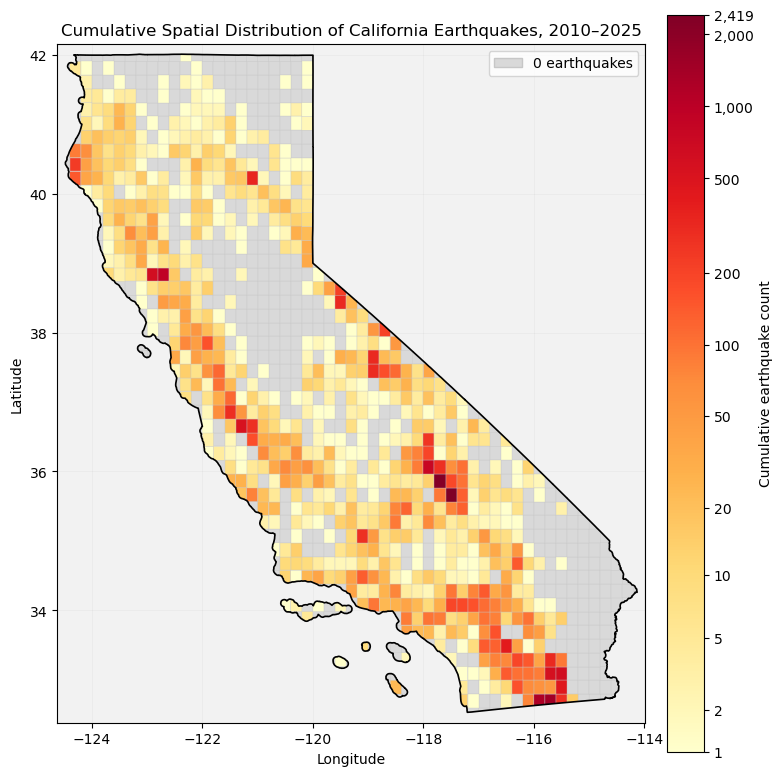

In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch


# ==================================================
# 1. Final harmonised catalogue
# ==================================================

if "df_final" not in globals():

    df_final = pd.read_csv(
        "earthquake_california_grid_2010_2025_Mw25_centre_mask.csv"
    )

    df_final["time"] = pd.to_datetime(
        df_final["time"],
        format="mixed",
        utc=True
    )


print(
    "Final harmonised earthquakes:",
    len(df_final)
)


# ==================================================
# 2. Build a DISPLAY-ONLY full California grid
#
#    Start from the complete bounding-box grid and
#    clip all cells that intersect California.
#
#    This is for visualisation only and does NOT
#    replace the 1,080-cell centre-based model grid.
# ==================================================

try:
    california_union = (
        california_boundary.geometry.union_all()
    )

except AttributeError:
    california_union = (
        california_boundary.geometry.unary_union
    )


display_grid = grid_gdf.copy()


# Clip every bounding-box grid cell to California
display_grid["geometry"] = (
    display_grid.geometry.intersection(
        california_union
    )
)


# Keep cells with a genuine positive-area intersection
display_grid = display_grid[
    display_grid.geometry.notna()
    & (~display_grid.geometry.is_empty)
    & (display_grid.geometry.area > 0)
].copy()


print(
    "Display-only intersecting cells:",
    len(display_grid)
)


# ==================================================
# 3. Count earthquakes using the FINAL harmonised data
# ==================================================

final_cell_counts = (
    df_final
    .groupby("cell_id")
    .size()
    .rename("total_count")
    .reset_index()
)


display_grid = display_grid.merge(
    final_cell_counts,
    on="cell_id",
    how="left"
)


# Cells outside the centre-based model mask have
# no df_final events and therefore appear as zero
# in this display-only boundary layer.
display_grid["total_count"] = (
    display_grid["total_count"]
    .fillna(0)
    .astype(int)
)


# Log transformation for colour display only
display_grid["log_total_count"] = np.log1p(
    display_grid["total_count"]
)


# ==================================================
# 4. Checks
# ==================================================

print(
    "Earthquakes represented:",
    display_grid["total_count"].sum()
)

print(
    "Maximum cumulative count:",
    display_grid["total_count"].max()
)

print(
    "Zero-count cells:",
    (display_grid["total_count"] == 0).sum()
)

print(
    "Positive-count cells:",
    (display_grid["total_count"] > 0).sum()
)


assert (
    display_grid["total_count"].sum()
    ==
    len(df_final)
)


# ==================================================
# 5. Separate zero and positive cells
# ==================================================

zero_cells = display_grid[
    display_grid["total_count"] == 0
].copy()

positive_cells = display_grid[
    display_grid["total_count"] > 0
].copy()


# ==================================================
# 6. Plot
# ==================================================

fig, ax = plt.subplots(
    figsize=(8, 10)
)

ax.set_facecolor(
    "#f2f2f2"
)


# --------------------------------------------------
# Plot zero-count cells in grey
# --------------------------------------------------

zero_cells.plot(
    ax=ax,
    facecolor="#d9d9d9",
    edgecolor="#c7c7c7",
    linewidth=0.25
)


# --------------------------------------------------
# Plot positive cells using log colour scale
# --------------------------------------------------

vmin = float(np.log1p(1))

vmax = float(
    positive_cells["log_total_count"].max()
)

norm = Normalize(
    vmin=vmin,
    vmax=vmax
)

positive_cells.plot(
    column="log_total_count",
    ax=ax,
    cmap="YlOrRd",
    norm=norm,
    edgecolor="#c7c7c7",
    linewidth=0.25,
    legend=False
)


# ==================================================
# 7. California boundary
# ==================================================

california_boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)


# ==================================================
# 8. Colourbar
#
#    Zero cells are shown separately in grey,
#    so the colourbar starts from count = 1.
# ==================================================

sm = ScalarMappable(
    norm=norm,
    cmap="YlOrRd"
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.76,
    pad=0.03
)

max_count = int(
    positive_cells["total_count"].max()
)

candidate_ticks = np.array([
    1,
    2,
    5,
    10,
    20,
    50,
    100,
    200,
    500,
    1000,
    2000,
    5000,
    10000
])

count_ticks = candidate_ticks[
    candidate_ticks <= max_count
]

if (
    max_count > 0
    and (
        len(count_ticks) == 0
        or count_ticks[-1] != max_count
    )
):
    count_ticks = np.append(
        count_ticks,
        max_count
    )

cbar.set_ticks(
    np.log1p(count_ticks)
)

cbar.set_ticklabels([
    f"{int(x):,}"
    for x in count_ticks
])

cbar.set_label(
    "Cumulative earthquake count"
)


# ==================================================
# 9. Legend for zero-count cells
# ==================================================

zero_patch = Patch(
    facecolor="#d9d9d9",
    edgecolor="#c7c7c7",
    label="0 earthquakes"
)

ax.legend(
    handles=[zero_patch],
    loc="upper right",
    frameon=True
)


# ==================================================
# 10. Map formatting
# ==================================================

minx, miny, maxx, maxy = (
    california_boundary.total_bounds
)

ax.set_xlim(
    minx - 0.15,
    maxx + 0.15
)

ax.set_ylim(
    miny - 0.15,
    maxy + 0.15
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "Cumulative Spatial Distribution of California Earthquakes, 2010–2025"
)

ax.grid(
    alpha=0.18,
    linewidth=0.4
)

ax.set_axisbelow(True)

plt.tight_layout()


# ==================================================
# 11. Save
# ==================================================

plt.savefig(
    "cumulative_spatial_earthquake_counts_harmonised_full_boundary_grey_zero.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "cumulative_spatial_earthquake_counts_harmonised_full_boundary_grey_zero.pdf",
    bbox_inches="tight"
)

plt.show()

In [9]:
# ============================================================
# 8. Rebuild daily count matrix and summarise sparsity
# ============================================================

dates = pd.date_range(
    f"{START_YEAR}-01-01",
    f"{END_YEAR}-12-31",
    freq="D"
)

cell_ids = np.sort(grid_mask["cell_id"].astype(int).unique())

df_daily = df_eda.copy()
df_daily["date"] = (
    df_daily["time"]
    .dt.floor("D")
    .dt.tz_localize(None)
)

daily_counts_25 = (
    df_daily.groupby(["date", "cell_id"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=dates,
        columns=cell_ids,
        fill_value=0
    )
)

daily_values = daily_counts_25.to_numpy().ravel()

n_total = daily_values.size
n_zero = int(np.sum(daily_values == 0))
n_positive = int(np.sum(daily_values > 0))

positive_values = daily_values[daily_values > 0]

print("Daily grid-cell sparsity")
print("------------------------")
print("Daily matrix shape:", daily_counts_25.shape)
print("Day-cell observations:", f"{n_total:,}")
print(
    "Zero observations:",
    f"{n_zero:,}",
    f"({100 * n_zero / n_total:.3f}%)"
)
print(
    "Positive observations:",
    f"{n_positive:,}",
    f"({100 * n_positive / n_total:.3f}%)"
)
print("Mean daily count:", daily_values.mean())
print("Median positive count:", np.median(positive_values))
print("Mean positive count:", positive_values.mean())
print("Maximum daily cell count:", positive_values.max())

assert daily_counts_25.to_numpy().sum() == len(df_eda)

print("\nConsistency check passed: daily matrix total equals catalogue total.")


Daily grid-cell sparsity
------------------------
Daily matrix shape: (5844, 1080)
Day-cell observations: 6,311,520
Zero observations: 6,293,977 (99.722%)
Positive observations: 17,543 (0.278%)
Mean daily count: 0.004808192004461683
Median positive count: 1.0
Mean positive count: 1.729863763324403
Maximum daily cell count: 1085

Consistency check passed: daily matrix total equals catalogue total.


In [10]:
eda_summary = pd.DataFrame({
    "quantity": [
        "final_events", "retained_cells", "active_cells", "inactive_cells",
        "daily_zero_observations", "daily_positive_observations",
        "maximum_daily_cell_count"
    ],
    "value": [
        len(df_eda), len(spatial_grid_counts), n_active, n_inactive,
        n_zero, n_positive, int(positive_values.max())
    ]
})
eda_summary.to_csv(TABLE_DIR / "eda_summary.csv", index=False)
display(eda_summary)

,quantity,value
0,final_events,30347
1,retained_cells,1080
2,active_cells,746
3,inactive_cells,334
4,daily_zero_observations,6293977
5,daily_positive_observations,17543
6,maximum_daily_cell_count,1085
